# Notebook 04 — Sentence Transformers & Visualisation 2D

Ce notebook couvre :
1. Encodage du corpus avec `all-MiniLM-L6-v2`
2. Fonction de recherche sémantique `search(query, k)`
3. Évaluation : Recall@10, Precision@10, MRR
4. Visualisation 2D des embeddings (t-SNE et UMAP)

## 1. Imports

In [1]:
import json
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

sns.set_theme(style='whitegrid')

DATA_DIR    = '../data'
MODELS_DIR  = '../models'
OUTPUTS_DIR = '../outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print('Imports OK')

Imports OK


## 2. Chargement des Données

In [2]:
df_docs = pd.read_pickle(os.path.join(DATA_DIR, 'df_docs_preprocessed.pkl'))

with open(os.path.join(DATA_DIR, 'queries_train.json'), 'r', encoding='utf-8') as f:
    queries_train = json.load(f)

with open(os.path.join(DATA_DIR, 'qgts_train.json'), 'r', encoding='utf-8') as f:
    qgts_train = json.load(f)

with open(os.path.join(DATA_DIR, 'queries_test.json'), 'r', encoding='utf-8') as f:
    queries_test = json.load(f)

id_to_idx = {doc_id: idx for idx, doc_id in enumerate(df_docs['id'])}
idx_to_id = {idx: doc_id for doc_id, idx in id_to_idx.items()}
corpus    = df_docs['content'].tolist()  # texte brut pour les embeddings

def get_relevant_ids(qgts, query_id):
    if query_id not in qgts:
        return []
    return [e['doc_id'] for e in qgts[query_id]['relevant_doc_ids']]

def build_query_text(q):
    parts = [q.get('text', ''), q.get('title', '')]
    if q.get('tags'):
        parts.append(' '.join(q['tags']))
    return ' '.join(p for p in parts if p).strip()

print(f'Corpus                 : {len(corpus):,} documents')
print(f'Requêtes train         : {len(queries_train)}')
print(f'Requêtes test          : {len(queries_test)}')

Corpus                 : 216,041 documents
Requêtes train         : 327
Requêtes test          : 141


## 3. Chargement du Modèle Sentence Transformer

In [3]:
MODEL_NAME = 'all-MiniLM-L6-v2'
print(f'Chargement du modèle : {MODEL_NAME}...')
model = SentenceTransformer(MODEL_NAME)
print('Modèle chargé.')

# Test sur un exemple
test_emb = model.encode(['Hello, this is a test sentence.'])
print(f'Dimension des embeddings : {test_emb.shape[1]}')

Chargement du modèle : all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé.
Dimension des embeddings : 384


## 4. Encodage du Corpus (Indexing)

In [4]:
EMBEDDINGS_CACHE = os.path.join(MODELS_DIR, 'corpus_embeddings.npy')

if os.path.exists(EMBEDDINGS_CACHE):
    print('Chargement des embeddings depuis le cache...')
    corpus_embeddings = np.load(EMBEDDINGS_CACHE)
else:
    print('Encodage du corpus (peut prendre plusieurs minutes sur CPU)...')
    corpus_embeddings = model.encode(
        corpus,
        batch_size=128,          # augmenté de 32 → 128 pour accélérer sur CPU
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True  # normalise L2 → cosine_similarity devient un simple produit scalaire
    )
    np.save(EMBEDDINGS_CACHE, corpus_embeddings)
    print('Embeddings sauvegardés en cache.')

print(f'Shape des embeddings : {corpus_embeddings.shape}')  # (n_docs, 384)

Encodage du corpus (peut prendre plusieurs minutes sur CPU)...


Batches:   0%|          | 0/1688 [00:00<?, ?it/s]

Embeddings sauvegardés en cache.
Shape des embeddings : (216041, 384)


## 5. Fonction de Recherche Sémantique

In [5]:
def search(query: str, k: int = 10) -> dict:
    """
    Recherche sémantique par similarité cosinus entre embeddings.

    Args:
        query: Requête en langage naturel.
        k: Nombre de résultats à retourner.

    Returns:
        dict avec 'topk_indices' et 'topk_scores'.
    """
    query_emb = model.encode([query], convert_to_numpy=True)  # (1, 384)
    scores    = cosine_similarity(query_emb, corpus_embeddings).flatten()
    top_k_idx = np.argsort(scores)[::-1][:k]
    return {
        'topk_indices': top_k_idx.tolist(),
        'topk_scores':  scores[top_k_idx].tolist()
    }

# Test
result = search('neural networks deep learning', k=5)
print('Top 5 résultats (Embeddings) pour "neural networks deep learning" :')
for idx, score in zip(result['topk_indices'], result['topk_scores']):
    print(f"  [{score:.4f}] {df_docs.iloc[idx]['id']} — {df_docs.iloc[idx]['title']}")

Top 5 résultats (Embeddings) pour "neural networks deep learning" :
  [0.4295] d1656f91-cbd0-4985-9ba6-7ad90646b7cb_16249 — Are neural networks the best approach to artificial intelligence and machine learning?
  [0.3937] 31cb537a-5f48-4bcb-a246-2abac3e52023_72093 — What is a Neural Network in simple words
  [0.3832] 8028d0f9-bd3f-4623-9430-41b30cd31981_218917 — Deriving an algorithm from its neural network representation
  [0.3676] d5a7ce7d-2b90-4797-910b-5e8bb47b1f1c_222516 — Support Vector Machines as Neural Nets?
  [0.3659] 6fd6dff4-dfef-48bf-85fa-09349b29d504_187648 — Can a neural network provide more than "yes" or "no" answers?


## 6. Évaluation

In [8]:
def recall_at_k(retrieved_indices, relevant_ids, k, id_to_idx):
    relevant_set = set(id_to_idx[rid] for rid in relevant_ids if rid in id_to_idx)
    retrieved_set = set(retrieved_indices[:k])
    if not relevant_set:
        return 0.0
    return len(relevant_set & retrieved_set) / len(relevant_set)

def precision_at_k(retrieved_indices, relevant_ids, k, id_to_idx):
    relevant_set = set(id_to_idx[rid] for rid in relevant_ids if rid in id_to_idx)
    retrieved_set = set(retrieved_indices[:k])
    if k == 0:
        return 0.0
    return len(relevant_set & retrieved_set) / k

def mrr(retrieved_indices, relevant_ids, id_to_idx):
    relevant_set = set(id_to_idx[rid] for rid in relevant_ids if rid in id_to_idx)
    for rank, idx in enumerate(retrieved_indices, start=1):
        if idx in relevant_set:
            return 1.0 / rank
    return 0.0

print('Fonctions de métriques définies : recall_at_k, precision_at_k, mrr')

Fonctions de métriques définies : recall_at_k, precision_at_k, mrr


In [9]:
K = 10
recalls, precisions, mrrs_list = [], [], []

for query_entry in queries_train:
    query_id     = query_entry['id']
    query_text   = build_query_text(query_entry)
    relevant_ids = get_relevant_ids(qgts_train, query_id)

    if not relevant_ids:
        continue

    result    = search(query_text, k=K)
    retrieved = result['topk_indices']

    recalls.append(recall_at_k(retrieved, relevant_ids, K, id_to_idx))
    precisions.append(precision_at_k(retrieved, relevant_ids, K, id_to_idx))
    mrrs_list.append(mrr(retrieved, relevant_ids, id_to_idx))

emb_results = {
    'model':           'SentenceTransformers',
    f'Recall@{K}':     np.mean(recalls),
    f'Precision@{K}':  np.mean(precisions),
    'MRR':             np.mean(mrrs_list)
}

print(f'Évaluation sur {len(recalls)} requêtes (avec ground truth)')
print('=== Résultats Sentence Transformers ===')
for key, val in emb_results.items():
    if isinstance(val, float):
        print(f'{key:20s}: {val:.4f}')
    else:
        print(f'{key:20s}: {val}')

Évaluation sur 327 requêtes (avec ground truth)
=== Résultats Sentence Transformers ===
model               : SentenceTransformers
Recall@10           : 0.1959
Precision@10        : 0.1141
MRR                 : 0.2745


In [10]:
# Sauvegarde
with open(os.path.join(OUTPUTS_DIR, 'embeddings_results.pkl'), 'wb') as f:
    pickle.dump(emb_results, f)
print('Résultats sauvegardés.')

Résultats sauvegardés.


## 7. Visualisation 2D des Embeddings (M-05)

# t-SNE sur un échantillon (216K docs trop volumineux pour t-SNE en entier)
SAMPLE_SIZE = 3000
np.random.seed(42)
sample_idx  = np.random.choice(len(corpus_embeddings), SAMPLE_SIZE, replace=False)
sample_emb  = corpus_embeddings[sample_idx]
sample_cats = [df_docs.iloc[i]['category'] for i in sample_idx]

print(f'Application de t-SNE sur {SAMPLE_SIZE} documents (échantillon)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, init='pca')
embeddings_2d_tsne = tsne.fit_transform(sample_emb)
print(f't-SNE terminé. Shape : {embeddings_2d_tsne.shape}')

In [15]:
# t-SNE sur un échantillon (216K docs trop volumineux pour t-SNE en entier)
SAMPLE_SIZE = 3000
np.random.seed(42)
sample_idx  = np.random.choice(len(corpus_embeddings), SAMPLE_SIZE, replace=False)
sample_emb  = corpus_embeddings[sample_idx]
sample_cats = [df_docs.iloc[i]['category'] for i in sample_idx]

print(f'Application de t-SNE sur {SAMPLE_SIZE} documents (échantillon)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, init='pca')
embeddings_2d_tsne = tsne.fit_transform(sample_emb)
print(f't-SNE terminé. Shape : {embeddings_2d_tsne.shape}')

Application de t-SNE sur 3000 documents (échantillon)...
t-SNE terminé. Shape : (3000, 2)


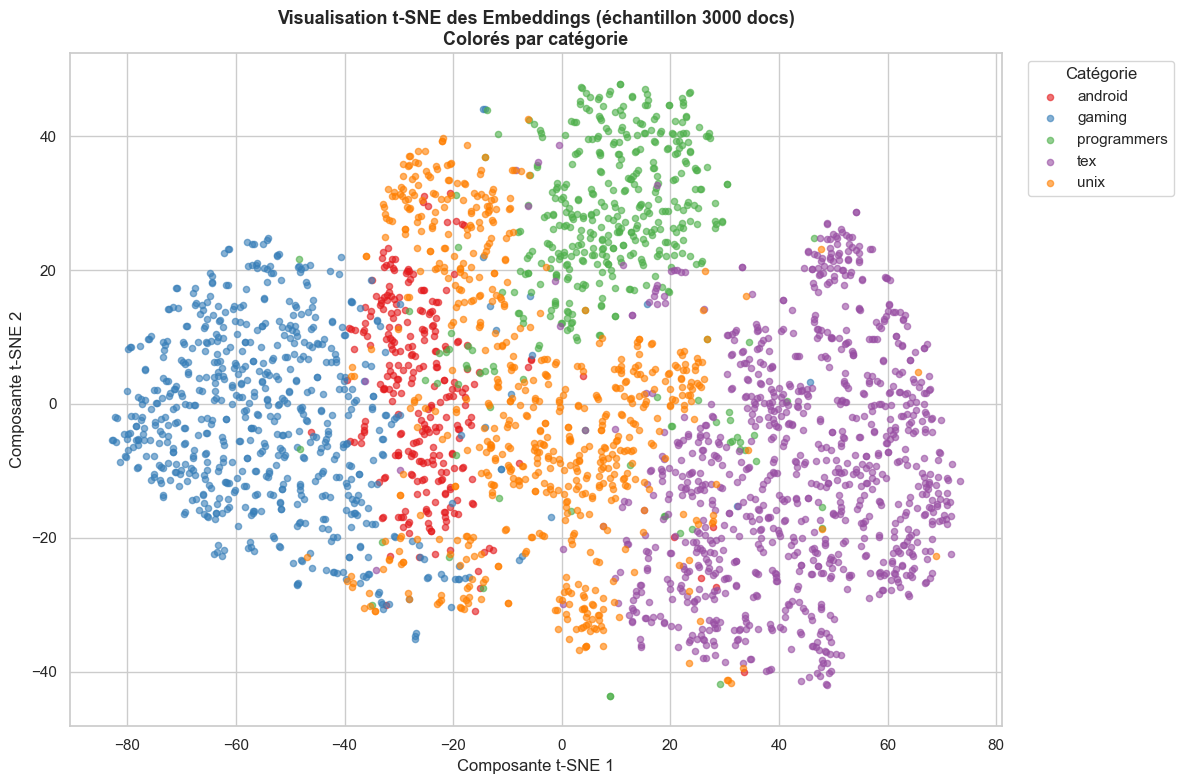

Visualisation t-SNE sauvegardée.


In [16]:
unique_cats  = sorted(set(sample_cats))
palette      = sns.color_palette('Set1', len(unique_cats))
cat_to_color = {cat: palette[i] for i, cat in enumerate(unique_cats)}

fig, ax = plt.subplots(figsize=(12, 8))
for cat in unique_cats:
    mask = np.array([c == cat for c in sample_cats])
    ax.scatter(embeddings_2d_tsne[mask, 0], embeddings_2d_tsne[mask, 1],
               label=cat, s=20, alpha=0.6, color=cat_to_color[cat])

ax.set_title(f'Visualisation t-SNE des Embeddings (échantillon {SAMPLE_SIZE} docs)\nColorés par catégorie',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Composante t-SNE 1')
ax.set_ylabel('Composante t-SNE 2')
ax.legend(title='Catégorie', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'embedding_viz_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Visualisation t-SNE sauvegardée.')

### 7.2 Réduction par UMAP (si disponible)

UMAP disponible. Application...


C:\Users\pclenovo\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


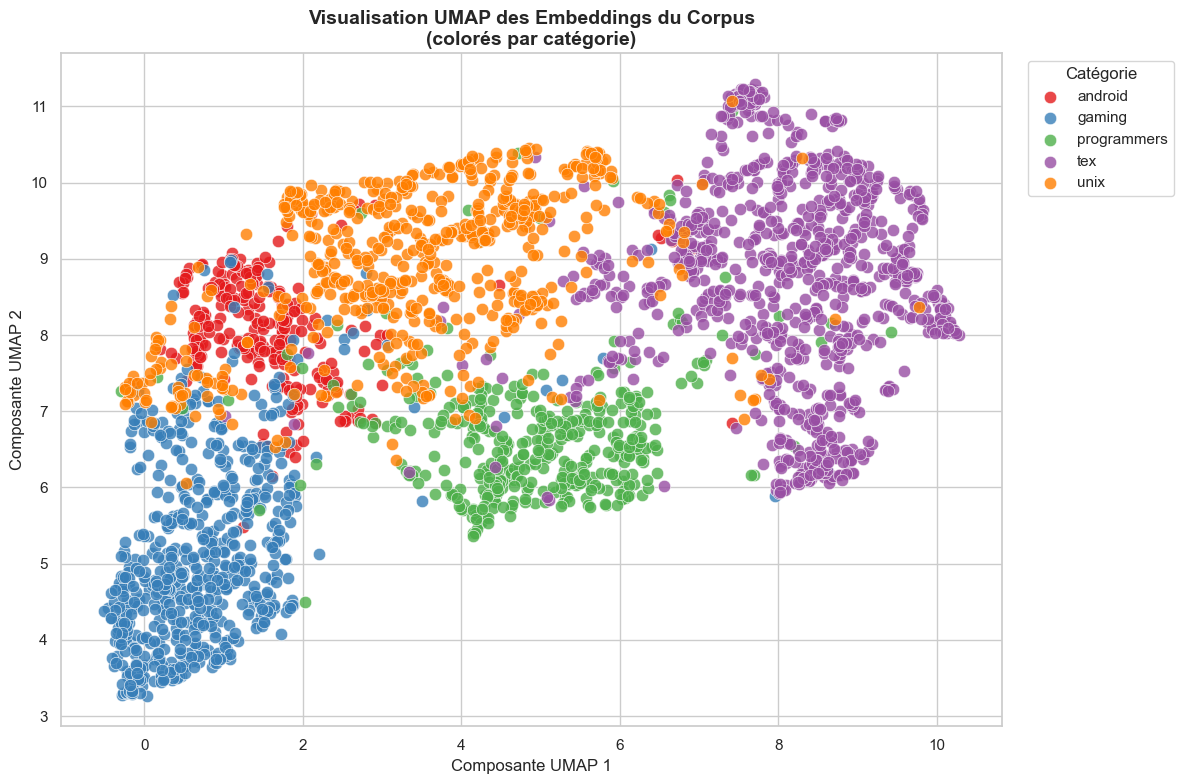

Visualisation UMAP sauvegardée.


In [18]:
try:
    import umap
    print('UMAP disponible. Application...')
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.1)
    embeddings_2d_umap = reducer.fit_transform(sample_emb)

    fig, ax = plt.subplots(figsize=(12, 8))
    for cat in unique_cats:
        mask = [c == cat for c in sample_cats]
        xs = embeddings_2d_umap[mask, 0]
        ys = embeddings_2d_umap[mask, 1]
        ax.scatter(xs, ys, label=cat, s=80, alpha=0.8, color=cat_to_color[cat], edgecolors='white', linewidths=0.5)

    ax.set_title('Visualisation UMAP des Embeddings du Corpus\n(colorés par catégorie)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Composante UMAP 1')
    ax.set_ylabel('Composante UMAP 2')
    ax.legend(title='Catégorie', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, 'embedding_viz_umap.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Visualisation UMAP sauvegardée.')

except ImportError:
    print('UMAP non disponible (pip install umap-learn). La visualisation t-SNE est utilisée.')

### 7.3 Interprétation

La visualisation 2D montre comment les documents sont répartis dans l'espace sémantique :

- **Clusters bien séparés** → le modèle capture bien les différences thématiques entre catégories
- **Documents proches de catégories voisines** → indique une similarité sémantique réelle (ex: `algorithms` et `machine_learning` partagent des concepts)
- **Points isolés** → documents thématiquement atypiques ou polyvalents

Une bonne séparabilité des catégories dans cet espace prédit une meilleure performance du classifieur de Phase 2.

## 8. Résumé

**Sentence Transformers (`all-MiniLM-L6-v2`) :**
- Dimension des embeddings : 384
- Encodage batch avec cache pour éviter le recalcul
- Recherche par similarité cosinus
- Interface : `search(query, k) -> {'topk_indices': [...], 'topk_scores': [...]}`

**Livrables :**
- `models/corpus_embeddings.npy` — Embeddings du corpus
- `outputs/embeddings_results.pkl` — Métriques d'évaluation
- `outputs/embedding_viz_tsne.png` — Visualisation t-SNE
- `outputs/embedding_viz_umap.png` — Visualisation UMAP (si disponible)